In [18]:
using CSV
using DataFrames
using Plots


In [14]:


data = """
name,input_file,seed,n,nnz,bytes,is_laplacian,is_sddm,sccs,tol,treat_as
anisotropic_poisson_grid_200000000_0,/tmp/data/anisotropic_poisson_grid_200000000_0.jld2,15698180486863115418,28652616,200006496,830134841,,,1,1.0e-8,sddm
high_contrast_poisson_grid_200000000_32,/tmp/data/high_contrast_poisson_grid_200000000_32.jld2,14482399382570843202,28652616,200006496,836967777,,,1,1.0e-8,sddm
sachdeva_star_700_350,/tmp/data/sachdeva_star_700_350.jld2,11876963183392607699,245001,171500701,18846388,,,1,1.0e-8,lap
weighted_boundary_chimera_10000000_1,/tmp/data/weighted_boundary_chimera_10000000_1.jld2,5334426756079444067,9953703,54191549,409504468,,,5125,1.0e-8,sddm
weighted_chimera_10000000_1,/tmp/data/weighted_chimera_10000000_1.jld2,13390085866912505236,10000000,54649712,412341206,,,1,1.0e-8,lap
"""

# Use IOBuffer to treat the string as an in-memory file
df0 = CSV.read(IOBuffer(data), DataFrame; types=Dict("seed" => Int128))

# Display the DataFrame
println(df0)

5×11 DataFrame
 Row │ name                               input_file                         seed                  n         nnz        bytes      is_laplacian  is_sddm  sccs   tol      treat_as 
     │ String                             String                             Int128                Int64     Int64      Int64      Missing       Missing  Int64  Float64  String7  
─────┼─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   1 │ anisotropic_poisson_grid_2000000…  /tmp/data/anisotropic_poisson_gr…  15698180486863115418  28652616  200006496  830134841       missing  missing      1   1.0e-8  sddm
   2 │ high_contrast_poisson_grid_20000…  /tmp/data/high_contrast_poisson_…  14482399382570843202  28652616  200006496  836967777       missing  missing      1   1.0e-8  sddm
   3 │ sachdeva_star_700_350              /tmp/data/sachdeva_star_700_350.…  118769631833926076

In [12]:
data = """
name,status,k_param,factorisation_time_s,nnz_lo,nnz_hi,solution_time_s,pcg_iters,relative_error
sachdeva_star_700_350,solved,1,142.697284,85872500,85872500,1.992478,1,2.8308235056082117e-13
sachdeva_star_700_350,solved,2,143.458309,85872500,85872500,1.951813,1,2.8308235056082117e-13
sachdeva_star_700_350,solved,3,143.575852,85872500,85872500,1.968659,1,2.8308235056082117e-13
sachdeva_star_700_350,solved,4,144.106494,85872500,85872500,1.958897,1,2.8308235056082117e-13
weighted_boundary_chimera_10000000_1,solved,1,95.433169,61539879,61539879,604.752528,133,8.495717436016712e-9
weighted_boundary_chimera_10000000_1,solved,2,227.017731,113383056,113383056,541.757309,83,8.96180126516271e-9
weighted_boundary_chimera_10000000_1,solved,3,633.517851,208055930,208055930,615.519123,66,9.832873138549388e-9
weighted_boundary_chimera_10000000_1,solved,4,1955.347071,373979449,373979449,721.913263,48,9.571148080745356e-9
weighted_chimera_10000000_1,solved,1,95.566794,62174860,62174860,877.886321,171,4.4219559295345556e-8
weighted_chimera_10000000_1,solved,2,231.810621,114823463,114823463,1357.346843,192,3.553624341352973e-8
weighted_chimera_10000000_1,solved,3,612.946781,211104362,211104362,1997.105265,200,1.4172851185339062e-8
weighted_chimera_10000000_1,solved,4,2029.592371,379997514,379997514,3054.188414,191,1.415112812823452e-8
anisotropic_poisson_grid_200000000_0,solved,1,56.291965,199726506,199726506,524.038918,125,9.54113932730775e-9
anisotropic_poisson_grid_200000000_0,solved,2,87.804221,341588716,341588716,582.813892,99,9.680231964168813e-9
anisotropic_poisson_grid_200000000_0,solved,3,179.806316,624754071,624754071,566.239103,70,9.95388237691913e-9
anisotropic_poisson_grid_200000000_0,solved,4,311.464598,1019920306,1019920306,580.462606,54,9.535295281346532e-9
high_contrast_poisson_grid_200000000_32,solved,1,62.593446,199726506,199726506,854.009206,190,1.7207813483854688e-8
high_contrast_poisson_grid_200000000_32,solved,2,101.405605,341588716,341588716,1028.828502,171,8.634517739405257e-9
high_contrast_poisson_grid_200000000_32,solved,3,206.207737,624754071,624754071,1043.549682,128,9.194500511552302e-9
high_contrast_poisson_grid_200000000_32,solved,4,361.28619,1019920306,1019920306,1080.071109,99,9.795838151810155e-9
"""

# Read the CSV data from the in-memory string
df1 = CSV.read(IOBuffer(data), DataFrame)

# Add a new column "method" with the constant value "ilu(k)" for each row
df1[!, :method] = fill("ilu(k)", nrow(df1))

# Display the resulting DataFrame
println(df1)

20×10 DataFrame
 Row │ name                               status   k_param  factorisation_time_s  nnz_lo      nnz_hi      solution_time_s  pcg_iters  relative_error  method 
     │ String                             String7  Int64    Float64               Int64       Int64       Float64          Int64      Float64         String 
─────┼───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   1 │ sachdeva_star_700_350              solved         1              142.697     85872500    85872500          1.99248          1     2.83082e-13  ilu(k)
   2 │ sachdeva_star_700_350              solved         2              143.458     85872500    85872500          1.95181          1     2.83082e-13  ilu(k)
   3 │ sachdeva_star_700_350              solved         3              143.576     85872500    85872500          1.96866          1     2.83082e-13  ilu(k)
   4 │ sachdeva_star_700_350           

In [13]:
data = """
name,status,k_param,factorisation_time_s,nnz_lo,nnz_hi,solution_time_s,pcg_iters,relative_error
sachdeva_star_700_350,solved,1,52.57730984687805,85875925,245001,486.3620219230652,479,9.800801528695791e-9
sachdeva_star_700_350,solved,2,96.84974598884583,85881617,245001,41.742647886276245,40,9.378791177194219e-9
weighted_boundary_chimera_10000000_1,solved,1,43.19305086135864,69939836,9953704,170.04833793640137,43,8.176790954911489e-9
weighted_boundary_chimera_10000000_1,solved,2,65.98656702041626,92658752,9953704,114.97536897659302,25,8.905668353032068e-9
weighted_chimera_10000000_1,solved,1,43.69702982902527,72838081,10000000,148.78267812728882,37,7.406818863106857e-9
weighted_chimera_10000000_1,solved,2,73.60763812065125,98582153,10000000,115.2944700717926,25,7.1264253970901634e-9
anisotropic_poisson_grid_200000000_0,solved,1,98.36545014381409,257795778,28652617,273.36111402511597,39,7.672147012875164e-9
anisotropic_poisson_grid_200000000_0,solved,2,194.7219741344452,347231580,28652617,274.3555040359497,26,6.245622522030597e-9
high_contrast_poisson_grid_200000000_32,solved,1,102.44643092155457,268466063,28652617,414.79075503349304,56,9.196648386115072e-9
high_contrast_poisson_grid_200000000_32,solved,2,205.35967302322388,371431718,28652617,527.0964210033417,45,9.158348318849312e-9
"""

# Read the CSV data from an in-memory string
df2 = CSV.read(IOBuffer(data), DataFrame)

# Add a new column "method" with the constant value "ac(k)"
df2[!, :method] = fill("ac(k)", nrow(df2))

# Display the resulting DataFrame
println(df2)

10×10 DataFrame
 Row │ name                               status   k_param  factorisation_time_s  nnz_lo     nnz_hi    solution_time_s  pcg_iters  relative_error  method 
     │ String                             String7  Int64    Float64               Int64      Int64     Float64          Int64      Float64         String 
─────┼────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   1 │ sachdeva_star_700_350              solved         1               52.5773   85875925    245001         486.362         479      9.8008e-9   ac(k)
   2 │ sachdeva_star_700_350              solved         2               96.8497   85881617    245001          41.7426         40      9.37879e-9  ac(k)
   3 │ weighted_boundary_chimera_100000…  solved         1               43.1931   69939836   9953704         170.048          43      8.17679e-9  ac(k)
   4 │ weighted_boundary_chimera_100000…  solved         2  

In [17]:
Tin = df0
Tiluk = df1
Tack = df2


# 1. Concatenate Tiluk and Tack vertically, then join with Tin on "name"
T = innerjoin(Tin, vcat(Tiluk, Tack), on = :name)

# 2. Print a summary of the joined DataFrame (rough equivalent to T.glimpse())
println("DataFrame Summary:")
describe(T)
println()

# 3. Select only the desired columns
T = select(T, [:name, :n, :nnz, :method, :k_param, :status, :nnz_lo, :nnz_hi, :pcg_iters, :relative_error])

# 4. Create a new column "fillin" computed as nnz_lo divided by nnz (elementwise)
T.fillin = T.nnz_lo ./ T.nnz

# 5. Sort the DataFrame by "name", "method", and "k_param"
T = sort(T, [:name, :method, :k_param])

# 6. Display the full DataFrame (all rows and columns)
show(T, allcols=true, allrows=true)

DataFrame Summary:

30×11 DataFrame
 Row │ name                               n         nnz        method  k_param  status   nnz_lo      nnz_hi      pcg_iters  relative_error  fillin   
     │ String                             Int64     Int64      String  Int64    String7  Int64       Int64       Int64      Float64         Float64  
─────┼───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   1 │ anisotropic_poisson_grid_2000000…  28652616  200006496  ac(k)         1  solved    257795778    28652617         39     7.67215e-9   1.28894
   2 │ anisotropic_poisson_grid_2000000…  28652616  200006496  ac(k)         2  solved    347231580    28652617         26     6.24562e-9   1.7361
   3 │ anisotropic_poisson_grid_2000000…  28652616  200006496  ilu(k)        1  solved    199726506   199726506        125     9.54114e-9   0.9986
   4 │ anisotropic_poisson_grid_2000000…  28652616  200006496  ilu(k)   

6×11 DataFrame
 Row │ name                               n        nnz       method  k_param  status   nnz_lo     nnz_hi     pcg_iters  relative_error  fillin  
     │ String                             Int64    Int64     String  Int64    String7  Int64      Int64      Int64      Float64         Float64 
─────┼──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   1 │ weighted_boundary_chimera_100000…  9953703  54191549  ac(k)         1  solved    69939836    9953704         43      8.17679e-9  1.2906
   2 │ weighted_boundary_chimera_100000…  9953703  54191549  ac(k)         2  solved    92658752    9953704         25      8.90567e-9  1.70984
   3 │ weighted_boundary_chimera_100000…  9953703  54191549  ilu(k)        1  solved    61539879   61539879        133      8.49572e-9  1.1356
   4 │ weighted_boundary_chimera_100000…  9953703  54191549  ilu(k)        2  solved   113383056  113383056         83  

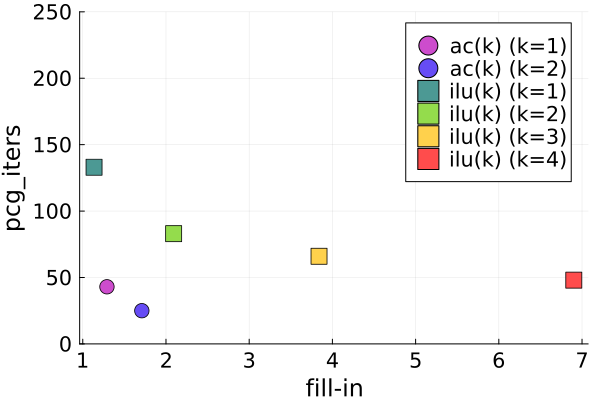

"/Users/rjkyng/Dropbox/Repos/2024-lap/SDDM2023/performance-analyses/scatter_wb.png"

In [65]:
# Assume T is already defined as in previous examples

# 1. Filter the DataFrame for the specific "name"
Twb = filter(row -> row.name == "weighted_boundary_chimera_10000000_1", T)

# Display the filtered DataFrame (all columns and rows)
show(Twb, allcols=true, allrows=true)

# 2. Group by :method and :k_param
grouped = groupby(Twb, [:method, :k_param])

# 3. Determine a unique color for each group using the Viridis palette
n_groups = length(grouped)
group_colors = palette(:lightrainbow, n_groups)

# 4. Initialize a blank plot with axis labels and title
plt = plot(xlabel = "fill-in", ylabel = "pcg_iters",
           xguidefont = font(16),    # larger x-axis label
           yguidefont = font(16),    # larger y-axis label
           legendfontsize = 14,      # larger legend text
           tickfont = font(14),      # larger tick labels
           ylims = (0, 250))     # set y-axis lower limit to 0

# 5. Loop over each group, set marker shape based on method, and plot with a unique color
for (i, subdf) in enumerate(grouped)
    # Construct label from method and k_param values (assumed constant per group)
    label_str = "$(subdf.method[1]) (k=$(subdf.k_param[1]))"
    
    # Choose marker shape: square for "ilu(k)" and circle otherwise
    marker_shape = (subdf.method[1] == "ilu(k)") ? :square : :circle

    # Plot the series; marker tuple: (shape, size)
    scatter!(plt, subdf.fillin, subdf.pcg_iters,
             label = label_str,
             marker = (marker_shape, 8),
             color = group_colors[i])
end


# 6. Display the plot
display(plt)

savefig(plt, "scatter_wb.png")

6×11 DataFrame
 Row │ name                         n         nnz       method  k_param  status   nnz_lo     nnz_hi     pcg_iters  relative_error  fillin  
     │ String                       Int64     Int64     String  Int64    String7  Int64      Int64      Int64      Float64         Float64 
─────┼─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   1 │ weighted_chimera_10000000_1  10000000  54649712  ac(k)         1  solved    72838081   10000000         37      7.40682e-9  1.33282
   2 │ weighted_chimera_10000000_1  10000000  54649712  ac(k)         2  solved    98582153   10000000         25      7.12643e-9  1.80389
   3 │ weighted_chimera_10000000_1  10000000  54649712  ilu(k)        1  solved    62174860   62174860        171      4.42196e-8  1.1377
   4 │ weighted_chimera_10000000_1  10000000  54649712  ilu(k)        2  solved   114823463  114823463        192      3.55362e-8  2.10108
   5 │ wei

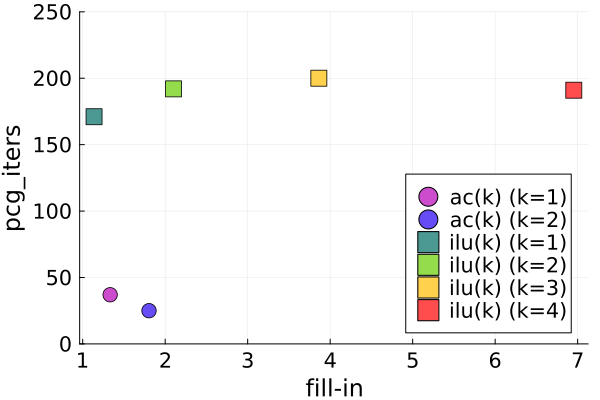

"/Users/rjkyng/Dropbox/Repos/2024-lap/SDDM2023/performance-analyses/scatter_wc.png"

In [63]:
# Assume T is already defined as in previous examples

# 1. Filter the DataFrame for the specific "name"
Twb = filter(row -> row.name == "weighted_chimera_10000000_1", T)

# Display the filtered DataFrame (all columns and rows)
show(Twb, allcols=true, allrows=true)

# 2. Group by :method and :k_param
grouped = groupby(Twb, [:method, :k_param])

# 3. Determine a unique color for each group using the Viridis palette
n_groups = length(grouped)
group_colors = palette(:lightrainbow, n_groups)

# 4. Initialize a blank plot with axis labels and title
plt = plot(xlabel = "fill-in", ylabel = "pcg_iters",
           xguidefont = font(16),    # larger x-axis label
           yguidefont = font(16),    # larger y-axis label
           legendfontsize = 14,      # larger legend text
           tickfont = font(14),      # larger tick labels
           ylims = (0, 250))     # set y-axis lower limit to 0

# 5. Loop over each group, set marker shape based on method, and plot with a unique color
for (i, subdf) in enumerate(grouped)
    # Construct label from method and k_param values (assumed constant per group)
    label_str = "$(subdf.method[1]) (k=$(subdf.k_param[1]))"
    
    # Choose marker shape: square for "ilu(k)" and circle otherwise
    marker_shape = (subdf.method[1] == "ilu(k)") ? :square : :circle

    # Plot the series; marker tuple: (shape, size)
    scatter!(plt, subdf.fillin, subdf.pcg_iters,
             label = label_str,
             marker = (marker_shape, 8),
             color = group_colors[i])
end


# 6. Display the plot
display(plt)

savefig(plt, "scatter_wc.png")

6×11 DataFrame
 Row │ name                               n         nnz        method  k_param  status   nnz_lo      nnz_hi      pcg_iters  relative_error  fillin  
     │ String                             Int64     Int64      String  Int64    String7  Int64       Int64       Int64      Float64         Float64 
─────┼──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   1 │ anisotropic_poisson_grid_2000000…  28652616  200006496  ac(k)         1  solved    257795778    28652617         39      7.67215e-9  1.28894
   2 │ anisotropic_poisson_grid_2000000…  28652616  200006496  ac(k)         2  solved    347231580    28652617         26      6.24562e-9  1.7361
   3 │ anisotropic_poisson_grid_2000000…  28652616  200006496  ilu(k)        1  solved    199726506   199726506        125      9.54114e-9  0.9986
   4 │ anisotropic_poisson_grid_2000000…  28652616  200006496  ilu(k)        2  solved    341588

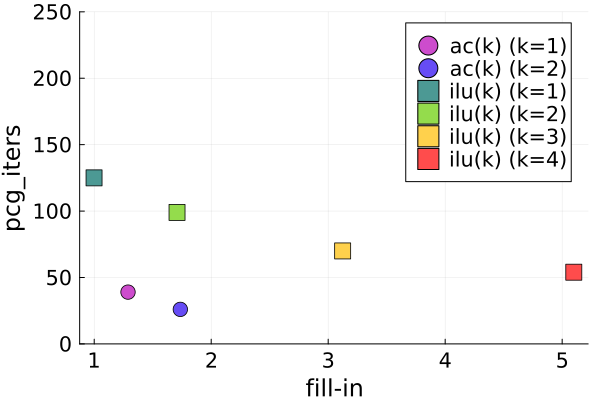

"/Users/rjkyng/Dropbox/Repos/2024-lap/SDDM2023/performance-analyses/scatter_an.png"

In [66]:
# Assume T is already defined as in previous examples

# 1. Filter the DataFrame for the specific "name"
Twb = filter(row -> row.name == "anisotropic_poisson_grid_200000000_0", T)

# Display the filtered DataFrame (all columns and rows)
show(Twb, allcols=true, allrows=true)

# 2. Group by :method and :k_param
grouped = groupby(Twb, [:method, :k_param])

# 3. Determine a unique color for each group using the Viridis palette
n_groups = length(grouped)
group_colors = palette(:lightrainbow, n_groups)

# 4. Initialize a blank plot with axis labels and title
plt = plot(xlabel = "fill-in", ylabel = "pcg_iters",
           xguidefont = font(16),    # larger x-axis label
           yguidefont = font(16),    # larger y-axis label
           legendfontsize = 14,      # larger legend text
           tickfont = font(14),      # larger tick labels
           ylims = (0, 250))     # set y-axis lower limit to 0

# 5. Loop over each group, set marker shape based on method, and plot with a unique color
for (i, subdf) in enumerate(grouped)
    # Construct label from method and k_param values (assumed constant per group)
    label_str = "$(subdf.method[1]) (k=$(subdf.k_param[1]))"
    
    # Choose marker shape: square for "ilu(k)" and circle otherwise
    marker_shape = (subdf.method[1] == "ilu(k)") ? :square : :circle

    # Plot the series; marker tuple: (shape, size)
    scatter!(plt, subdf.fillin, subdf.pcg_iters,
             label = label_str,
             marker = (marker_shape, 8),
             color = group_colors[i])
end


# 6. Display the plot
display(plt)

savefig(plt, "scatter_an.png")

6×11 DataFrame
 Row │ name                               n         nnz        method  k_param  status   nnz_lo      nnz_hi      pcg_iters  relative_error  fillin  
     │ String                             Int64     Int64      String  Int64    String7  Int64       Int64       Int64      Float64         Float64 
─────┼──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   1 │ high_contrast_poisson_grid_20000…  28652616  200006496  ac(k)         1  solved    268466063    28652617         56      9.19665e-9  1.34229
   2 │ high_contrast_poisson_grid_20000…  28652616  200006496  ac(k)         2  solved    371431718    28652617         45      9.15835e-9  1.8571
   3 │ high_contrast_poisson_grid_20000…  28652616  200006496  ilu(k)        1  solved    199726506   199726506        190      1.72078e-8  0.9986
   4 │ high_contrast_poisson_grid_20000…  28652616  200006496  ilu(k)        2  solved    341588

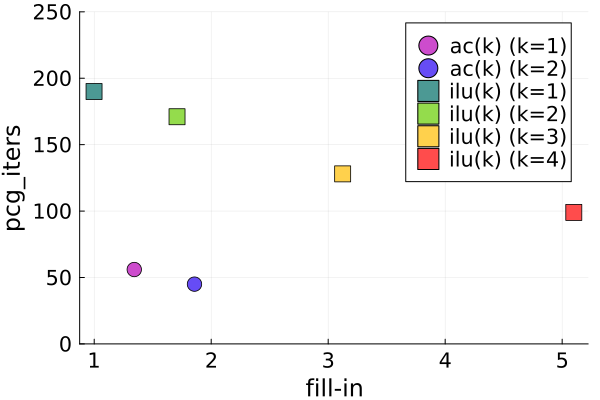

"/Users/rjkyng/Dropbox/Repos/2024-lap/SDDM2023/performance-analyses/scatter_hc.png"

In [61]:
# Assume T is already defined as in previous examples

# 1. Filter the DataFrame for the specific "name"
Twb = filter(row -> row.name == "high_contrast_poisson_grid_200000000_32", T)

# Display the filtered DataFrame (all columns and rows)
show(Twb, allcols=true, allrows=true)

# 2. Group by :method and :k_param
grouped = groupby(Twb, [:method, :k_param])

# 3. Determine a unique color for each group using the Viridis palette
n_groups = length(grouped)
group_colors = palette(:lightrainbow, n_groups)

# 4. Initialize a blank plot with axis labels and title
plt = plot(xlabel = "fill-in", ylabel = "pcg_iters",
           xguidefont = font(16),    # larger x-axis label
           yguidefont = font(16),    # larger y-axis label
           legendfontsize = 14,      # larger legend text
           tickfont = font(14),      # larger tick labels
           ylims = (0, 250))     # set y-axis lower limit to 0

# 5. Loop over each group, set marker shape based on method, and plot with a unique color
for (i, subdf) in enumerate(grouped)
    # Construct label from method and k_param values (assumed constant per group)
    label_str = "$(subdf.method[1]) (k=$(subdf.k_param[1]))"
    
    # Choose marker shape: square for "ilu(k)" and circle otherwise
    marker_shape = (subdf.method[1] == "ilu(k)") ? :square : :circle

    # Plot the series; marker tuple: (shape, size)
    scatter!(plt, subdf.fillin, subdf.pcg_iters,
             label = label_str,
             marker = (marker_shape, 8),
             color = group_colors[i])
end


# 6. Display the plot
display(plt)

savefig(plt, "scatter_hc.png")

6×11 DataFrame
 Row │ name                   n       nnz        method  k_param  status   nnz_lo    nnz_hi    pcg_iters  relative_error  fillin   
     │ String                 Int64   Int64      String  Int64    String7  Int64     Int64     Int64      Float64         Float64  
─────┼─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   1 │ sachdeva_star_700_350  245001  171500701  ac(k)         1  solved   85875925    245001        479     9.8008e-9    0.500732
   2 │ sachdeva_star_700_350  245001  171500701  ac(k)         2  solved   85881617    245001         40     9.37879e-9   0.500765
   3 │ sachdeva_star_700_350  245001  171500701  ilu(k)        1  solved   85872500  85872500          1     2.83082e-13  0.500712
   4 │ sachdeva_star_700_350  245001  171500701  ilu(k)        2  solved   85872500  85872500          1     2.83082e-13  0.500712
   5 │ sachdeva_star_700_350  245001  171500701  ilu(k)        3 

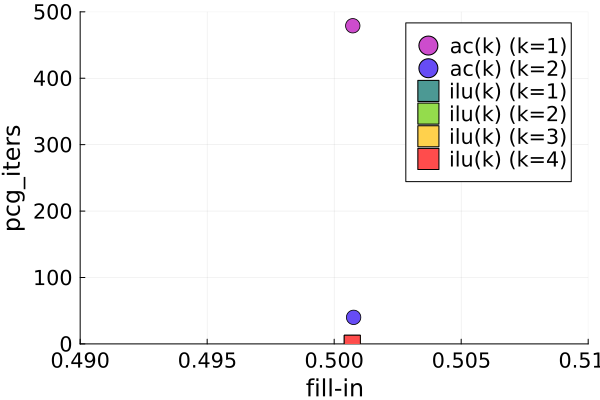

"/Users/rjkyng/Dropbox/Repos/2024-lap/SDDM2023/performance-analyses/scatter_ss.png"

In [67]:
# Assume T is already defined as in previous examples

# 1. Filter the DataFrame for the specific "name"
Twb = filter(row -> row.name == "sachdeva_star_700_350", T)

# Display the filtered DataFrame (all columns and rows)
show(Twb, allcols=true, allrows=true)

# 2. Group by :method and :k_param
grouped = groupby(Twb, [:method, :k_param])

# 3. Determine a unique color for each group using the Viridis palette
n_groups = length(grouped)
group_colors = palette(:lightrainbow, n_groups)

# 4. Initialize a blank plot with axis labels and title
plt = plot(xlabel = "fill-in", ylabel = "pcg_iters",
           xguidefont = font(16),    # larger x-axis label
           yguidefont = font(16),    # larger y-axis label
           legendfontsize = 14,      # larger legend text
           tickfont = font(14),      # larger tick labels
           ylims = (0, 500),     # set y-axis lower limit to 0
           xlims = (0.49, 0.51)) # set x-axis 



# 5. Loop over each group, set marker shape based on method, and plot with a unique color
for (i, subdf) in enumerate(grouped)
    # Construct label from method and k_param values (assumed constant per group)
    label_str = "$(subdf.method[1]) (k=$(subdf.k_param[1]))"
    
    # Choose marker shape: square for "ilu(k)" and circle otherwise
    marker_shape = (subdf.method[1] == "ilu(k)") ? :square : :circle

    # Plot the series; marker tuple: (shape, size)
    scatter!(plt, subdf.fillin, subdf.pcg_iters,
             label = label_str,
             marker = (marker_shape, 8),
             color = group_colors[i])
end


# 6. Display the plot
display(plt)

savefig(plt, "scatter_ss.png")